<a href="https://colab.research.google.com/github/lricci03/Hands-on-ML/blob/main/c13_ex9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13 - Exercise 9
Tweak the Seq2SeqModel model to forecast both rail and bus ridership for the next 14 days.
The model will now need to predict 28 values instead of 14.

## Train & Evaluate Functions

In [1]:
import sys

assert sys.version_info >= (3, 10)

In [2]:
%pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.0 MB/s eta 0:00:00


In [3]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [53]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=20, factor=0.1):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

## Download the data

Download the ridership data from the ageron/data project. It originally comes from Chicago's Transit Authority, and was downloaded from the [Chicago's Data Portal](https://homl.info/ridership).

In [6]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

download_and_extract_ridership_data()

Clean up the data

In [7]:
import pandas as pd
from pathlib import Path

path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

## Preparing the data for RNN

In [8]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end]
        target = self.series[end]
        return window, target

### Seq2SeqDataset

In [9]:
class MulvarTimeSeriesDataset(TimeSeriesDataset):
    def __getitem__(self, idx):
        window, target = super().__getitem__(idx)
        return window, target[:2]

In [56]:
class MulvarForecastAheadDataset(MulvarTimeSeriesDataset):
    def __len__(self):
        return len(self.series) - self.window_length - 14 + 1

    def __getitem__(self, idx):
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end]
        target = self.series[end : end + 14]
        return window, target

In [57]:
class Seq2SeqDataset(MulvarForecastAheadDataset):
    def __getitem__(self, idx):
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end]
        target_period = self.series[idx + 1 : end + 14]
        target = target_period.unfold(dimension=0, size=14, step=1)
        return window, target

### Train, Valid, Test Sets

In [28]:
from torch.utils.data import DataLoader
torch.manual_seed(0)

In [29]:
df_rail_bus = df[["rail", "bus"]] / 1e6  # use both rail & bus series as input

In [58]:
rail_bus_train = torch.FloatTensor(df_rail_bus["2016-01":"2018-12"].values)
rail_bus_valid = torch.FloatTensor(df_rail_bus["2019-01":"2019-05"].values)
rail_bus_test = torch.FloatTensor(df_rail_bus["2019-06":].values)

In [59]:
window_length = 56
rail_bus_train_set = Seq2SeqDataset(rail_bus_train, window_length)
rail_bus_train_loader = DataLoader(rail_bus_train_set, batch_size=32, shuffle=True)
rail_bus_valid_set = Seq2SeqDataset(rail_bus_valid, window_length)
rail_bus_valid_loader = DataLoader(rail_bus_valid_set, batch_size=32)
rail_bus_test_set = Seq2SeqDataset(rail_bus_test, window_length)
rail_bus_test_loader = DataLoader(rail_bus_test_set, batch_size=32)

## RNN Model

In [18]:
import torch.nn as nn
import torchmetrics

torch.manual_seed(42)

In [60]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])

In [61]:
for X, y in rail_bus_train_loader:
  print(y.shape)

torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([32, 56, 2, 14])
torch.Size([3, 56, 2, 14])


The shape of the targets is [32, 56, 2, 14] where
* 32 = batch size
* 56 = time window
* 2 = number of features (trail, bus)
* 14 = time steps ahead

We must format the outputs in the same way for the loss-function inside our train() function to work.

In SimpleRnnModel the output layer outputs a [batch size, time window, output_size=28], so we need to change it into [batch size, time window, 2, 14]

In [62]:
class Seq2SeqRnnModel(SimpleRnnModel):
    def forward(self, X):
        B, L, _ = X.shape # B=batch size, L= time window (_ would be the number of features)
        outputs, last_state = self.rnn(X)
        # the shape of outputs is B,L, hidden_size
        pred = self.output(outputs) # the shape is B, L, output_size=28
        return pred.view(B,L,2,14) # reshaped into B, L, 2, 14

## Train

In [66]:
import torch.nn as nn
import torchmetrics

torch.manual_seed(42)
seq_model = Seq2SeqRnnModel(input_size = 2, hidden_size =32, output_size = 28)
seq_model = seq_model.to(device)

In [67]:
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(seq_model.parameters(), lr=1.0, momentum=0.95)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(seq_model, optimizer, loss_fn, metric, rail_bus_train_loader,
                rail_bus_valid_loader, n_epochs=50, patience=5, factor=0.5)

Epoch 1/50, train loss: 0.0464, train metric: 0.2412, valid metric: 0.1533
Epoch 2/50, train loss: 0.0145, train metric: 0.1343, valid metric: 0.1041
Epoch 3/50, train loss: 0.0070, train metric: 0.0856, valid metric: 0.0760
Epoch 4/50, train loss: 0.0055, train metric: 0.0733, valid metric: 0.0867
Epoch 5/50, train loss: 0.0053, train metric: 0.0698, valid metric: 0.0715
Epoch 6/50, train loss: 0.0048, train metric: 0.0644, valid metric: 0.0637
Epoch 7/50, train loss: 0.0046, train metric: 0.0624, valid metric: 0.0726
Epoch 8/50, train loss: 0.0047, train metric: 0.0628, valid metric: 0.0621
Epoch 9/50, train loss: 0.0047, train metric: 0.0648, valid metric: 0.0748
Epoch 10/50, train loss: 0.0046, train metric: 0.0631, valid metric: 0.0584
Epoch 11/50, train loss: 0.0044, train metric: 0.0603, valid metric: 0.0558
Epoch 12/50, train loss: 0.0043, train metric: 0.0592, valid metric: 0.0589
Epoch 13/50, train loss: 0.0043, train metric: 0.0582, valid metric: 0.0548
Epoch 14/50, train lo

In [68]:
min(history["valid_metrics"]) * 1e6

51797.740161418915

## Evaluate

In [69]:
seq_model.eval()
Y_pred_valid = [seq_model(X.to(device)) for X, _ in rail_bus_valid_loader]
Y_pred_valid = torch.cat(Y_pred_valid, dim=0)
Y_valid = torch.cat([Y.to(device) for _, Y in rail_bus_valid_loader], dim=0)
for idx, name in enumerate(["bus", "rail"]):
    mae = (Y_pred_valid[:, idx] - Y_valid[:, idx]).abs().mean()
    print(name, int(mae * 1e6))

bus 144327
rail 129110


## Use the model to predict

In [70]:
seq_model.eval()
with torch.no_grad():
    some_window = rail_bus_valid[:window_length]  # shape [56, 2]
    X = some_window.unsqueeze(dim=0)            # shape [1, 56, 2]
    Y_preds = seq_model(X.to(device))    # shape [1, 56, 2, 14]
    Y_pred = Y_preds[0, -1]                     # shape [2, 14]

Plot the predictions

Defalut font sizes to make everything look prettier

In [72]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

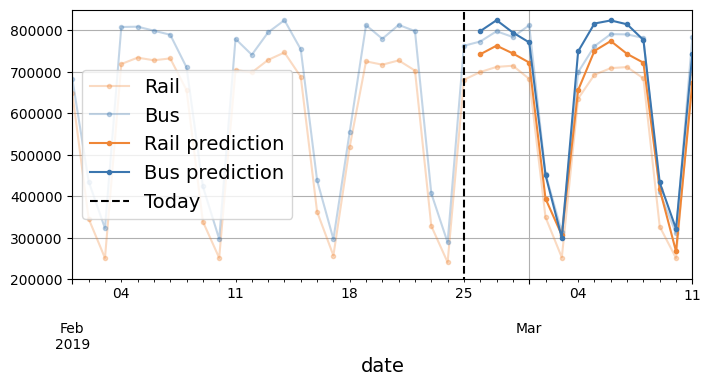

In [73]:
Y_pred_rail_s = pd.Series(Y_pred[0].cpu() * 1e6,
                          index=pd.date_range("2019-02-26", "2019-03-11"))
Y_pred_bus_s = pd.Series(Y_pred[1].cpu() * 1e6,
                         index=pd.date_range("2019-02-26", "2019-03-11"))
fig, ax = plt.subplots(figsize=(8, 3.5))
df["2019-02-01":"2019-03-11"]["rail"].plot(label="Rail", marker=".", ax=ax,
                                           color="#ef8636", alpha=0.3)
df["2019-02-01":"2019-03-11"]["bus"].plot(label="Bus", marker=".", ax=ax,
                                          color="#3b76af", alpha=0.3)
Y_pred_rail_s.plot(grid=True, marker=".", ax=ax, color="#ef8636",
                   label="Rail prediction")
Y_pred_bus_s.plot(grid=True, marker=".", ax=ax, color="#3b76af",
                  label="Bus prediction")
ax.vlines("2019-02-25", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 850_000])
plt.legend(loc="center left")
plt.show()